Suppose that we have four observations, for which we compute a dissimilarity matrix.
For instance, the dissimilarity between the first and second obser- vations is 0.3, and the dissimilarity between the second and fourth observations is 0.8.
(a) On the basis of this dissimilarity matrix, sketch the dendrogram that results from hierarchically clustering these four observa- tions using complete linkage. Be sure to indicate on the plot the height at which each fusion occurs, as well as the observations corresponding to each leaf in the dendrogram.

%Clustering steps%
Step 1: Find the smallest dissimilarity (excluding zeros on the diagonal), which is 0.3 between observations 1 and 2. Merge (1,2) at height 0.3.
Step 2: Update the dissimilarities with the new cluster (1,2):
Distance between (1,2) and 3: max(0.4, 0.5) = 0.5
Distance between (1,2) and 4: max(0.7, 0.8) = 0.8
Step 3: Next smallest dissimilarity is 0.45 between observation 3 and 4. Merge (3,4) at height 0.45.
Step 4: Update the dissimilarity between clusters (1,2) and (3,4):
max(0.5, 0.8) = 0.8
Step 5: Merge the clusters (1,2) and (3,4) at height 0.8.

%Dendrogram sketch (description)%
Leaves: 1, 2, 3, 4
Merge 1 and 2 at height 0.3
Merge 3 and 4 at height 0.45
Merge the two clusters (1,2) and (3,4) at height 0.8


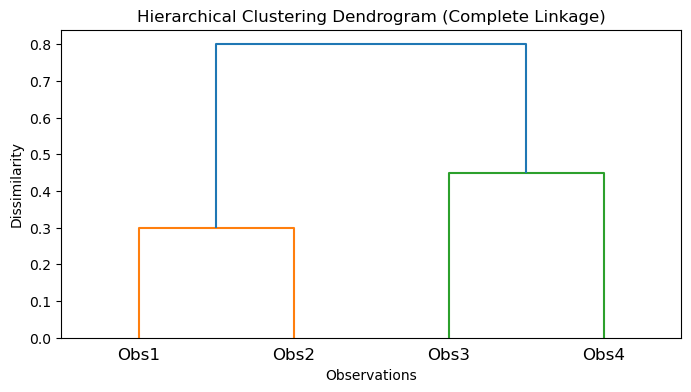

In [1]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import numpy as np

# 定義距離矩陣（對稱矩陣）
dissimilarity_matrix = np.array([
    [0, 0.3, 0.4, 0.7],
    [0.3, 0, 0.5, 0.8],
    [0.4, 0.5, 0, 0.45],
    [0.7, 0.8, 0.45, 0]
])

# 轉換為condensed form（scipy要求的格式）
condensed_dissimilarity = sch.distance.squareform(dissimilarity_matrix)

# 使用 complete linkage 進行層級聚類
linked = sch.linkage(condensed_dissimilarity, method='complete')

# 畫出樹狀圖
plt.figure(figsize=(8, 4))
sch.dendrogram(linked, labels=['Obs1', 'Obs2', 'Obs3', 'Obs4'])
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('Observations')
plt.ylabel('Dissimilarity')
plt.show()

(b) Repeat (a), this time using single linkage clustering.

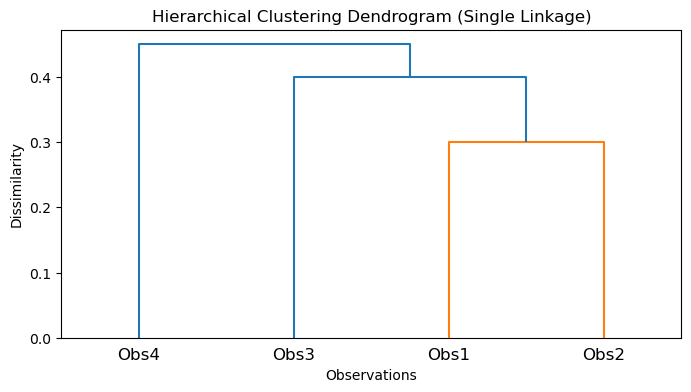

In [3]:
# 使用 single linkage 進行層級聚類
linked_single = sch.linkage(condensed_dissimilarity, method='single')

# 畫出樹狀圖
plt.figure(figsize=(8, 4))
sch.dendrogram(linked_single, labels=['Obs1', 'Obs2', 'Obs3', 'Obs4'])
plt.title('Hierarchical Clustering Dendrogram (Single Linkage)')
plt.xlabel('Observations')
plt.ylabel('Dissimilarity')
plt.show()

(c) Suppose that we cut the dendrogram obtained in (a) such that two clusters result. Which observations are in each cluster?

In [33]:
# 轉換成 condensed 形式
condensed_dissimilarity = sch.distance.squareform(dissimilarity_matrix)

# 使用單連結法進行層級聚類
Z = sch.linkage(condensed_dissimilarity, method='complete')

# 設定剪裁高度
cut_height = 0.7 #(小於 0.8, 大於等於 0.45)

# 取得簇
clusters = sch.fcluster(Z, t=cut_height, criterion='distance')

# 輸出結果
for i, c in enumerate(clusters, start=1):
    print(f'Observation {i} belongs to cluster {c}')

Observation 1 belongs to cluster 1
Observation 2 belongs to cluster 1
Observation 3 belongs to cluster 2
Observation 4 belongs to cluster 2


(d) Suppose that we cut the dendrogram obtained in (b) such that two clusters result. Which observations are in each cluster?

In (b), the original clusters are as follows:
Cluster 1: Observations 1 and 2 (merged at height 0.3);
Cluster 2: Cluster 1 and 3 (merged at height 0.4);
Cluster 3: Cluster 2 and 4 (merged at height 0.45).

In [29]:
# 轉換成 condensed 形式
condensed_dissimilarity = sch.distance.squareform(dissimilarity_matrix)

# 使用單連結法進行層級聚類
Z = sch.linkage(condensed_dissimilarity, method='single')

# 設定剪裁高度
cut_height = 0.4 #(小於 0.45, 大於等於 0.4)

# 取得簇
clusters = sch.fcluster(Z, t=cut_height, criterion='distance')

# 輸出結果
for i, c in enumerate(clusters, start=1):
    print(f'Observation {i} belongs to cluster {c}')

Observation 1 belongs to cluster 1
Observation 2 belongs to cluster 1
Observation 3 belongs to cluster 1
Observation 4 belongs to cluster 2


(e) It is mentioned in this chapter that at each fusion in the den- drogram, the position of the two clusters being fused can be swapped without changing the meaning of the dendrogram. Draw a dendrogram that is equivalent to the dendrogram in (a), for which two or more of the leaves are repositioned, but for which the meaning of the dendrogram is the same.

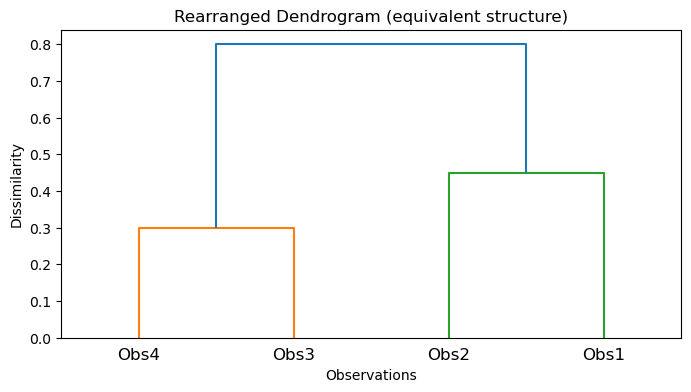

In [39]:
# 使用完全連結法，得到原始樹狀結構
Z = sch.linkage(condensed_dissimilarity, method='complete')

plt.figure(figsize=(8, 4))
sch.dendrogram(Z, labels=['Obs4', 'Obs3', 'Obs2', 'Obs1'], leaf_rotation=0) # 例如將觀測值1與4位置交換，2與3位置交換
plt.title('Rearranged Dendrogram (equivalent structure)')
plt.xlabel('Observations')
plt.ylabel('Dissimilarity')
plt.show()